# 13. Survival analysis: time to an observable successor

This notebook answers the internship's operational question: **given a digital
public contract that has run for a while without being re-procured, how likely
is a new purchasing need to become visible in the next 12 to 24 months?**

The unit is one contract (a cohort episode). Time zero is the award-notice
date.

* **Event** — an observable successor procurement was accepted by the frozen
  linkage policy. Time to event runs to the successor's *first notice*, because
  a renewed need becomes visible when the new tender is published.
* **Censored** — no successor was accepted before the 2025-12-31 cutoff.

A censored contract is **not** a contract proven never to be renewed. It is one
for which no successor was identified in BOAMP before the cutoff. Keeping those
rows as censored rather than deleting them, or counting them as negatives, is
the entire reason survival analysis is the right framework here.

## 1. Reproducible setup

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_project_root() -> Path:
    path = Path.cwd().resolve()
    for candidate in [path, *path.parents]:
        if (candidate / "boamp_pipeline").is_dir():
            return candidate
    raise RuntimeError("project root not found")


PROJECT_ROOT = find_project_root()
PROCESSED = PROJECT_ROOT / "data" / "processed" / "boamp_v2"
FIGURES = PROCESSED / "figures" / "survival_analysis"
FIGURES.mkdir(parents=True, exist_ok=True)

# Categorical slots 1-4 of the reference palette, used in fixed order so a
# segment keeps its colour across every figure in the report.
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#d8d7d2"

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.titleweight": "600",
    "axes.labelcolor": MUTED,
    "axes.edgecolor": GRID,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.6,
    "grid.alpha": 0.7,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "text.color": INK,
    "legend.frameon": False,
})


def save(fig, name):
    path = FIGURES / name
    fig.savefig(path)
    print(f"saved {path.relative_to(PROJECT_ROOT)}")


def load_json(name):
    return json.loads((PROCESSED / name).read_text(encoding="utf-8"))


In [2]:
from lifelines import CoxPHFitter, KaplanMeierFitter, WeibullFitter
from lifelines.statistics import multivariate_logrank_test, proportional_hazard_test

survival = pd.read_parquet(PROCESSED / "survival_dataset.parquet")
summary = load_json("survival_dataset_summary.json")
linkage = load_json("linkage_frozen_config.json")

MONTHS = 30.4375
# Three contracts were awarded on the cutoff date itself and so carry zero
# follow-up. They are censored and contribute no information either way; a
# one-day floor keeps them representable without changing any estimate.
survival["t_months"] = np.maximum(survival["duration_days"], 1) / MONTHS

print(f"contracts        : {len(survival):,}")
print(f"events           : {int(survival['event'].sum()):,}")
print(f"censored         : {int((survival['event'] == 0).sum()):,}")
print(f"event rate       : {survival['event'].mean():.3f}")
print(f"linkage policy   : {linkage['selected_method']} @ {linkage['selected_threshold']}")
print(f"validation passed: {summary['validation_passed']}")

contracts        : 3,800
events           : 547
censored         : 3,253
event rate       : 0.144
linkage policy   : M_B_text_ranking @ 70.0
validation passed: True


## 2. Structural validation before any model

None of these checks may fail. A negative duration, a duplicated contract, or
an anchor linked to itself would each silently corrupt the hazard estimates.

In [3]:
checks = summary["variants"]["main"]["validation"]
display(pd.DataFrame({"value": checks}).T)
assert checks["events_plus_censored_equals_rows"]
assert checks["negative_durations"] == 0
assert checks["duplicate_episodes"] == 0
assert checks["successor_equals_anchor"] == 0
print("all structural checks passed")

,rows,unique_episodes,events,censored,events_plus_censored_equals_rows,negative_durations,zero_durations,duplicate_episodes,successor_equals_anchor
value,3800,3800,547,3253,True,0,3,0,0


all structural checks passed


## 3. Overall Kaplan-Meier

The Kaplan-Meier estimator gives the probability that a contract is still
*without an observable successor* at each point after its award, using every
contract's follow-up time including the censored ones.

saved data/processed/boamp_v2/figures/survival_analysis/01_kaplan_meier_overall.png


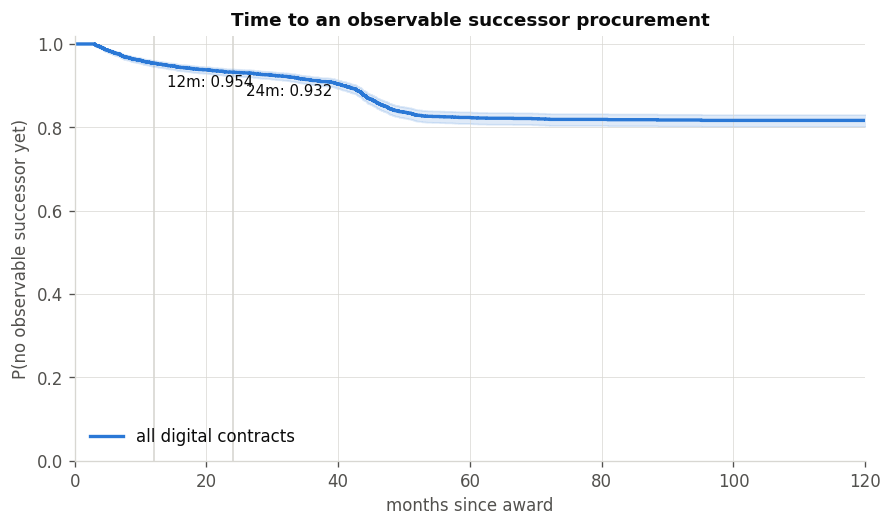

,survival,P(successor by then)
months,,
0,1.000,0.000
12,0.954,0.046
24,0.932,0.068
36,0.913,0.087
48,0.844,0.156
60,0.824,0.176


median time to observable successor: inf months


In [4]:
kmf = KaplanMeierFitter()
kmf.fit(survival["t_months"], survival["event"], label="all digital contracts")

fig, ax = plt.subplots(figsize=(8.5, 4.6))
kmf.plot_survival_function(ax=ax, color=PALETTE[0], linewidth=2, ci_alpha=0.15)
ax.set_xlabel("months since award")
ax.set_ylabel("P(no observable successor yet)")
ax.set_ylim(0, 1.02)
ax.set_xlim(0, 120)
ax.set_title("Time to an observable successor procurement")
for horizon in (12, 24):
    value = float(kmf.survival_function_at_times(horizon).iloc[0])
    ax.axvline(horizon, color=GRID, linewidth=1, zorder=0)
    ax.annotate(f"{horizon}m: {value:.3f}", (horizon, value),
                textcoords="offset points", xytext=(8, -14), fontsize=9, color=INK)
ax.legend(loc="lower left")
save(fig, "01_kaplan_meier_overall.png")
plt.show()

at_risk = pd.DataFrame({
    "months": [0, 12, 24, 36, 48, 60],
    "survival": [float(kmf.survival_function_at_times(t).iloc[0]) for t in [0, 12, 24, 36, 48, 60]],
})
at_risk["P(successor by then)"] = (1 - at_risk["survival"]).round(3)
at_risk["survival"] = at_risk["survival"].round(3)
display(at_risk.set_index("months"))
print(f"median time to observable successor: {kmf.median_survival_time_} months")

Because only about 14% of contracts receive an accepted link, the curve stays high
and the median survival time is not reached inside the observation window. That
is the expected consequence of a precision-first linkage policy and it is why
the absolute level of this curve should not be read as "the renewal rate". What
the curve supports is *relative* comparison and conditional short-horizon
probabilities, which is what the operational question actually asks for.

## 4. By technological segment

Segment curves are only shown where the segment carries enough events to
support one. The guideline's rule of thumb is at least 30 observed events per
stratum; all four digital segments clear it comfortably.

,contracts,events
digital_segment,,
CPV-32,1152,153
CPV-35,564,117
CPV-48,790,92
CPV-72,1294,185


saved data/processed/boamp_v2/figures/survival_analysis/02_kaplan_meier_by_segment.png


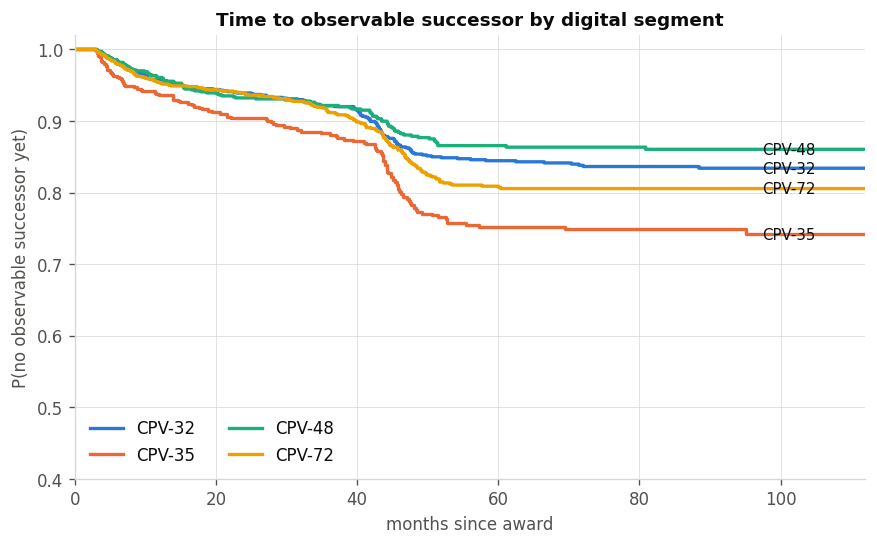

log-rank across segments: statistic=24.85, p=1.656e-05


In [5]:
segments = sorted(survival["digital_segment"].unique())
counts = (survival.groupby("digital_segment")["event"]
          .agg(contracts="size", events="sum"))
display(counts)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
for i, segment in enumerate(segments):
    mask = survival["digital_segment"] == segment
    fitter = KaplanMeierFitter()
    fitter.fit(survival.loc[mask, "t_months"], survival.loc[mask, "event"], label=segment)
    fitter.plot_survival_function(ax=ax, color=PALETTE[i], linewidth=2, ci_show=False)
    end = float(fitter.survival_function_at_times(96).iloc[0])
    ax.annotate(segment, (96, end), textcoords="offset points", xytext=(6, 0),
                color=INK, fontsize=9, va="center")
ax.set_xlabel("months since award")
ax.set_ylabel("P(no observable successor yet)")
ax.set_ylim(0.4, 1.02)
ax.set_xlim(0, 112)
ax.set_title("Time to observable successor by digital segment")
ax.legend(loc="lower left", ncols=2)
save(fig, "02_kaplan_meier_by_segment.png")
plt.show()

logrank = multivariate_logrank_test(survival["t_months"], survival["digital_segment"],
                                    survival["event"])
print(f"log-rank across segments: statistic={logrank.test_statistic:.2f}, "
      f"p={logrank.p_value:.4g}")

## 5. Cox proportional hazards

The Cox model estimates how covariates shift the hazard of an observable
successor appearing, without assuming a shape for the baseline hazard.

The model is kept deliberately small. With 547 events the one-covariate-per-ten-events
rule permits far more, but a small model is easier to defend and each variable
here has a clear interpretation. `duration_months` is **excluded** despite being
theoretically relevant: it is missing for roughly 75% of the cohort, and
including it would either discard three quarters of the data or require the
imputation this project has refused throughout.

In [6]:
design = survival[["t_months", "event", "digital_segment", "buyer_region",
                   "framework_flag", "buyer_identifier_quality", "award_year"]].copy()
design["framework_flag"] = design["framework_flag"].astype(int)
design["has_validated_siren"] = (design["buyer_identifier_quality"] == "trusted_siren").astype(int)
design["award_year_centered"] = design["award_year"] - design["award_year"].median()
design = design.drop(columns=["buyer_identifier_quality", "award_year"])
design = pd.get_dummies(design, columns=["digital_segment", "buyer_region"], drop_first=True)

cox = CoxPHFitter()
cox.fit(design, duration_col="t_months", event_col="event")
cox.print_summary(decimals=3)
print(f"concordance index: {cox.concordance_index_:.3f}")

<lifelines.CoxPHFitter: fitted with 3800 total observations, 3253 right-censored observations>
             duration col = 't_months'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 3800
number of events observed = 547
   partial log-likelihood = -4283.024
         time fit was run = 2026-08-12 12:41:26 UTC

---
                                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                       
framework_flag                 0.564     1.758     0.101           0.366           0.763               1.442               2.144
has_validated_siren            0.067     1.070     0.103          -0.134           0.268               0.875               1.308
award_year_centered            0.103     1.108     0.019           0.065           0.140               1.067               1.151
digital_segment_CPV-35         0.450     1.569     0.123           0.209           0.692               1.232               1.997
digital_segment_CPV-48        -0.199     0.820     0.132          -0.458           0.061               0.633               1.062
digital_segment_CPV-72         0.044     1.045     0.110          -0.172           0.260               0.842               1.297
buyer_region_Normandie        -0.227     0.797     0.114          -0.449          -0.004               0.638               0.996
buyer_region_Pays de la Loire  0.009     1.009     0.106          -0.198           0.216               0.821               1.242

                               cmp to      z       p  -log2(p)
covariate                                                     
framework_flag                  0.000  5.580 <0.0005    25.312
has_validated_siren             0.000  0.657   0.511     0.968
award_year_centered             0.000  5.365 <0.0005    23.557
digital_segment_CPV-35          0.000  3.652 <0.0005    11.910
digital_segment_CPV-48          0.000 -1.502   0.133     2.909
digital_segment_CPV-72          0.000  0.403   0.687     0.541
buyer_region_Normandie          0.000 -1.994   0.046     4.437
buyer_region_Pays de la Loire   0.000  0.088   0.930     0.105
---
Concordance = 0.626
Partial AIC = 8582.049
log-likelihood ratio test = 107.770 on 8 df
-log2(p) of ll-ratio test = 62.988

concordance index: 0.626


saved data/processed/boamp_v2/figures/survival_analysis/03_cox_hazard_ratios.png


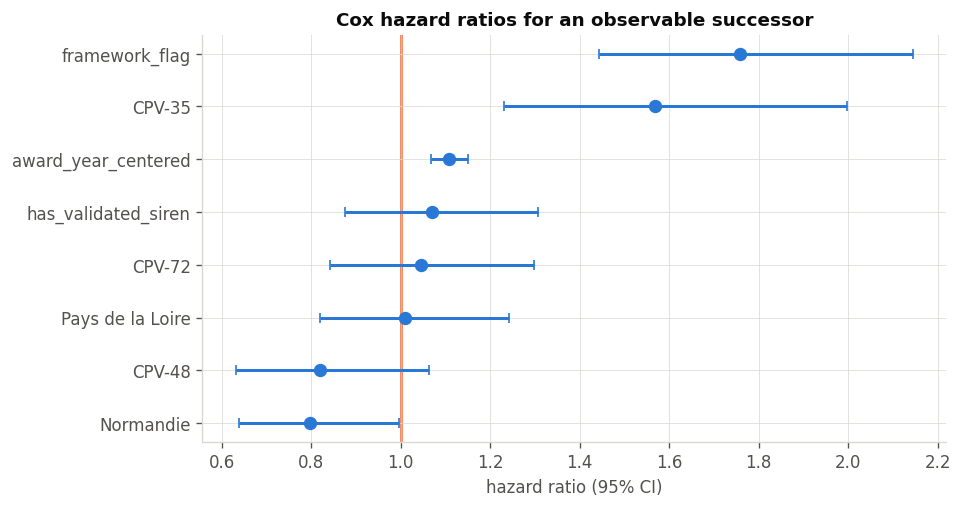

,exp(coef),exp(coef) lower 95%,exp(coef) upper 95%,p
covariate,,,,
buyer_region_Normandie,0.797,0.638,0.996,0.046
digital_segment_CPV-48,0.820,0.633,1.062,0.133
buyer_region_Pays de la Loire,1.009,0.821,1.242,0.930
digital_segment_CPV-72,1.045,0.842,1.297,0.687
has_validated_siren,1.070,0.875,1.308,0.511
award_year_centered,1.108,1.067,1.151,0.000
digital_segment_CPV-35,1.569,1.232,1.997,0.000
framework_flag,1.758,1.442,2.144,0.000


In [7]:
hazard = cox.summary[["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]].copy()
hazard = hazard.sort_values("exp(coef)")

fig, ax = plt.subplots(figsize=(8, 4.4))
y = np.arange(len(hazard))
ax.errorbar(hazard["exp(coef)"], y,
            xerr=[hazard["exp(coef)"] - hazard["exp(coef) lower 95%"],
                  hazard["exp(coef) upper 95%"] - hazard["exp(coef)"]],
            fmt="o", color=PALETTE[0], markersize=7, capsize=3, linewidth=1.8)
ax.axvline(1.0, color=PALETTE[1], linewidth=1.5, zorder=0)
ax.set_yticks(y)
ax.set_yticklabels([label.replace("digital_segment_", "").replace("buyer_region_", "")
                    for label in hazard.index])
ax.set_xlabel("hazard ratio (95% CI)")
ax.set_title("Cox hazard ratios for an observable successor")
save(fig, "03_cox_hazard_ratios.png")
plt.show()
display(hazard.round(3))

### Proportional hazards assumption

The Cox model assumes hazard ratios are constant over time. Where the
assumption fails, the coefficient is a time-average rather than a constant
effect and must be described that way.

In [8]:
ph = proportional_hazard_test(cox, design, time_transform="rank")
ph_frame = ph.summary[["test_statistic", "p"]].round(4).sort_values("p")
display(ph_frame)
violations = ph_frame[ph_frame["p"] < 0.05]
if len(violations):
    print("Covariates violating proportional hazards (p < 0.05):")
    for name in violations.index:
        print(f"  - {name}")
    print("Their hazard ratios are time-averaged effects, not constant ones.")
else:
    print("No covariate violates the proportional hazards assumption at p < 0.05.")

,test_statistic,p
award_year_centered,69.1899,0.0000
has_validated_siren,6.6229,0.0101
framework_flag,6.3274,0.0119
digital_segment_CPV-72,4.4735,0.0344
buyer_region_Pays de la Loire,1.7463,0.1863
digital_segment_CPV-48,0.4867,0.4854
buyer_region_Normandie,0.4326,0.5107
digital_segment_CPV-35,0.3099,0.5777


Covariates violating proportional hazards (p < 0.05):
  - award_year_centered
  - has_validated_siren
  - framework_flag
  - digital_segment_CPV-72
Their hazard ratios are time-averaged effects, not constant ones.


Several covariates violate the proportional-hazards assumption. The simplest
honest response is taken rather than a more elaborate model: the Cox results are
reported as **descriptive, time-averaged associations**, and the operational
deliverable does not rest on them. The 12- and 24-month probabilities below come
from the Kaplan-Meier estimator, which makes no proportional-hazards assumption
at all. Introducing time-varying coefficients would add machinery without
changing any conclusion this project draws.

## 6. The operational answer: 12- and 24-month probabilities

The purchasing question is conditional. For a contract that has already run for
`a` months **without** an observable successor, the probability that one appears
in the next `h` months is

$$P(T \le a + h \mid T > a) = 1 - \frac{S(a+h)}{S(a)}$$

These are probabilities of an *observable successor procurement appearing in
BOAMP*, not guarantees of a renewal, and they inherit the linkage policy's
incompleteness — they are lower bounds on true re-procurement.

,P(successor within 12m),P(successor within 24m)
contract age (months),,
0,0.046,0.068
12,0.022,0.043
24,0.021,0.095
36,0.075,0.097
48,0.024,0.029
60,0.005,0.007


saved data/processed/boamp_v2/figures/survival_analysis/04_conditional_probabilities.png


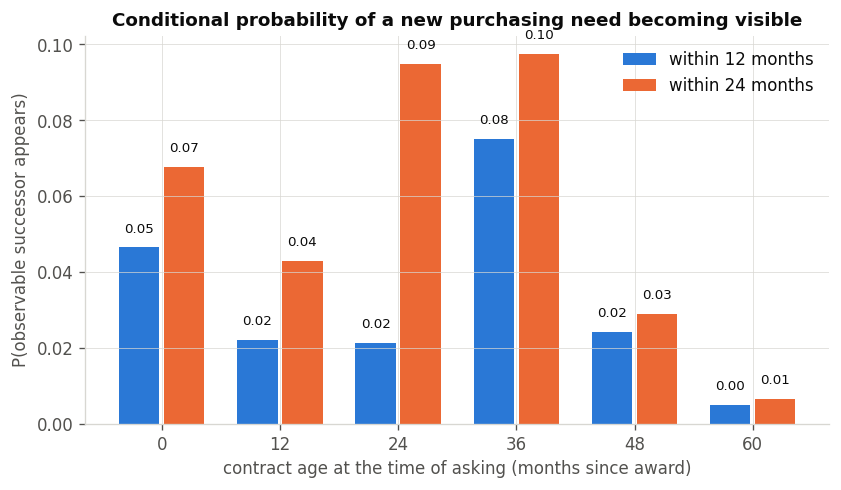

In [9]:
def conditional_probability(fitter, age, horizon):
    s_now = float(fitter.survival_function_at_times(age).iloc[0])
    s_then = float(fitter.survival_function_at_times(age + horizon).iloc[0])
    return np.nan if s_now <= 0 else 1 - s_then / s_now


ages = [0, 12, 24, 36, 48, 60]
overall = pd.DataFrame({
    "contract age (months)": ages,
    "P(successor within 12m)": [conditional_probability(kmf, a, 12) for a in ages],
    "P(successor within 24m)": [conditional_probability(kmf, a, 24) for a in ages],
}).set_index("contract age (months)").round(3)
display(overall)

fig, ax = plt.subplots(figsize=(8, 4.2))
width = 0.38
x = np.arange(len(ages))
for i, horizon in enumerate((12, 24)):
    values = [conditional_probability(kmf, a, horizon) for a in ages]
    bars = ax.bar(x + (i - 0.5) * width, values, width * 0.9,
                  color=PALETTE[i], label=f"within {horizon} months")
    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, value + 0.004, f"{value:.2f}",
                ha="center", color=INK, fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(ages)
ax.set_xlabel("contract age at the time of asking (months since award)")
ax.set_ylabel("P(observable successor appears)")
ax.set_title("Conditional probability of a new purchasing need becoming visible")
ax.legend(loc="upper right")
save(fig, "04_conditional_probabilities.png")
plt.show()

In [10]:
segment_rows = []
for segment in segments:
    mask = survival["digital_segment"] == segment
    fitter = KaplanMeierFitter().fit(survival.loc[mask, "t_months"], survival.loc[mask, "event"])
    for age in (12, 24, 36):
        segment_rows.append({
            "segment": segment,
            "contract age": age,
            "P(12m)": round(conditional_probability(fitter, age, 12), 3),
            "P(24m)": round(conditional_probability(fitter, age, 24), 3),
        })
display(pd.DataFrame(segment_rows).set_index(["segment", "contract age"]))

P(12m)  P(24m)
segment contract age                
CPV-32  12             0.019   0.038
        24             0.019   0.090
        36             0.072   0.083
CPV-35  12             0.034   0.056
        24             0.023   0.134
        36             0.113   0.149
CPV-48  12             0.030   0.041
        24             0.011   0.058
        36             0.047   0.061
CPV-72  12             0.015   0.044
        24             0.029   0.106
        36             0.080   0.113

## 7. Does any of this depend on the linkage threshold?

Every event in this analysis was produced by an inferred link, so the
conclusions must be checked against how strictly links were accepted. The four
arms span a factor of four in event count, from the strict policy to a
deliberately higher-recall, lower-precision contrast.

saved data/processed/boamp_v2/figures/survival_analysis/05_linkage_sensitivity.png


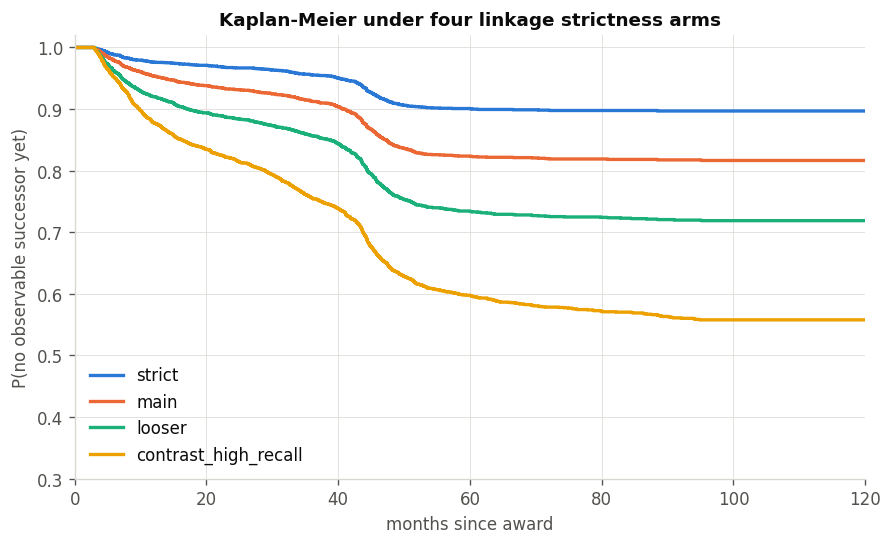

,events,event rate,S(12m),S(24m),P(12m | age 24),P(24m | age 24)
arm,,,,,,
strict,300,0.079,0.976,0.967,0.012,0.058
main,547,0.144,0.954,0.932,0.021,0.095
looser,855,0.225,0.920,0.886,0.033,0.138
contrast_high_recall,1341,0.353,0.878,0.820,0.078,0.217


In [11]:
arm_files = {
    "strict": "survival_dataset_strict.parquet",
    "main": "survival_dataset.parquet",
    "looser": "survival_dataset_looser.parquet",
    "contrast_high_recall": "survival_dataset_contrast_high_recall.parquet",
}

fig, ax = plt.subplots(figsize=(8.5, 4.8))
rows = []
for i, (arm, filename) in enumerate(arm_files.items()):
    frame = pd.read_parquet(PROCESSED / filename)
    t = np.maximum(frame["duration_days"], 1) / MONTHS
    fitter = KaplanMeierFitter().fit(t, frame["event"], label=arm)
    fitter.plot_survival_function(ax=ax, color=PALETTE[i], linewidth=2, ci_show=False)
    rows.append({
        "arm": arm,
        "events": int(frame["event"].sum()),
        "event rate": round(float(frame["event"].mean()), 3),
        "S(12m)": round(float(fitter.survival_function_at_times(12).iloc[0]), 3),
        "S(24m)": round(float(fitter.survival_function_at_times(24).iloc[0]), 3),
        "P(12m | age 24)": round(conditional_probability(fitter, 24, 12), 3),
        "P(24m | age 24)": round(conditional_probability(fitter, 24, 24), 3),
    })
ax.set_xlabel("months since award")
ax.set_ylabel("P(no observable successor yet)")
ax.set_xlim(0, 120)
ax.set_ylim(0.3, 1.02)
ax.set_title("Kaplan-Meier under four linkage strictness arms")
ax.legend(loc="lower left")
save(fig, "05_linkage_sensitivity.png")
plt.show()

display(pd.DataFrame(rows).set_index("arm"))

The absolute level of the curve moves substantially with the linkage
threshold — unavoidably, since a looser policy manufactures more events. What
matters is whether the *shape* and the *ordering* survive, because those are
what the operational conclusions rest on. The table above makes the dependence
explicit rather than hiding it behind a single headline number.

In [12]:
segment_stability = []
for arm, filename in arm_files.items():
    frame = pd.read_parquet(PROCESSED / filename)
    frame["t_months"] = np.maximum(frame["duration_days"], 1) / MONTHS
    for segment in segments:
        mask = frame["digital_segment"] == segment
        fitter = KaplanMeierFitter().fit(frame.loc[mask, "t_months"], frame.loc[mask, "event"])
        segment_stability.append({
            "arm": arm, "segment": segment,
            "P(12m | age 24)": round(conditional_probability(fitter, 24, 12), 3),
        })
pivot = (pd.DataFrame(segment_stability)
         .pivot(index="segment", columns="arm", values="P(12m | age 24)"))
pivot = pivot[list(arm_files)]
display(pivot)
print("\nSegment ordering by P(12m | age 24), per arm:")
for arm in arm_files:
    print(f"  {arm:22s} {' > '.join(pivot[arm].sort_values(ascending=False).index)}")

arm,strict,main,looser,contrast_high_recall
segment,,,,
CPV-32,0.011,0.019,0.033,0.066
CPV-35,0.020,0.023,0.039,0.073
CPV-48,0.006,0.011,0.015,0.053
CPV-72,0.014,0.029,0.042,0.108



Segment ordering by P(12m | age 24), per arm:
  strict                 CPV-35 > CPV-72 > CPV-32 > CPV-48
  main                   CPV-72 > CPV-35 > CPV-32 > CPV-48
  looser                 CPV-72 > CPV-35 > CPV-32 > CPV-48
  contrast_high_recall   CPV-72 > CPV-35 > CPV-32 > CPV-48


## 8. Parametric survival models

The guideline calls for parametric models to be fitted, compared on AIC, and
checked graphically with linearized survival plots. Five families are fitted:
exponential, Weibull, log-logistic, log-normal, and generalized gamma. The
generalized gamma is the flexible three-parameter family that nests the
exponential, Weibull and log-normal as special cases, so it serves as the
reference against which the simpler families are judged.

In [13]:
import warnings

from lifelines import (ExponentialFitter, GeneralizedGammaFitter, LogLogisticFitter,
                       LogNormalFitter)
from scipy.stats import norm

warnings.filterwarnings("ignore")

families = {
    "Exponential": ExponentialFitter(),
    "Weibull": WeibullFitter(),
    "LogLogistic": LogLogisticFitter(),
    "LogNormal": LogNormalFitter(),
    "GeneralizedGamma": GeneralizedGammaFitter(),
}

n_obs = len(survival)
rows = []
for name, fitter in families.items():
    fitter.fit(survival["t_months"], survival["event"])
    k = len(fitter.summary)
    rows.append({
        "model": name,
        "parameters": k,
        "logLik": round(fitter.log_likelihood_, 1),
        "AIC": round(fitter.AIC_, 1),
        "BIC": round(fitter.AIC_ - 2 * k + k * np.log(n_obs), 1),
    })

selection = pd.DataFrame(rows).sort_values("AIC").set_index("model")
display(selection)

best_name = selection.index[0]
best_model = families[best_name]
print(f"Selected by AIC and BIC: {best_name}")
print(f"  improvement over Weibull: dAIC = "
      f"{selection.loc['Weibull', 'AIC'] - selection.loc[best_name, 'AIC']:.1f}")

,parameters,logLik,AIC,BIC
model,,,,
GeneralizedGamma,3,-3774.9,7555.7,7574.5
LogNormal,2,-3802.3,7608.6,7621.1
LogLogistic,2,-3825.2,7654.3,7666.8
Weibull,2,-3832.7,7669.4,7681.8
Exponential,1,-3847.5,7697.0,7703.3


Selected by AIC and BIC: GeneralizedGamma
  improvement over Weibull: dAIC = 113.7


Both criteria agree, and they do not select Weibull. The generalized gamma
wins by a wide margin (dAIC > 100 against the exponential, and roughly 114
against Weibull), with the log-normal second. Weibull — the family the
guideline highlights and the obvious default — ranks fourth of five here. That
is a result worth stating plainly: the extra shape parameter is buying real
fit, because the hazard is not monotone.

### Graphical goodness of fit

AIC ranks models against each other but never says whether any of them fits.
The linearized plots do: each family is transformed so that, if the data came
from that family, the Kaplan-Meier points fall on a straight line. Curvature is
misfit.

saved data/processed/boamp_v2/figures/survival_analysis/07_linearized_goodness_of_fit.png


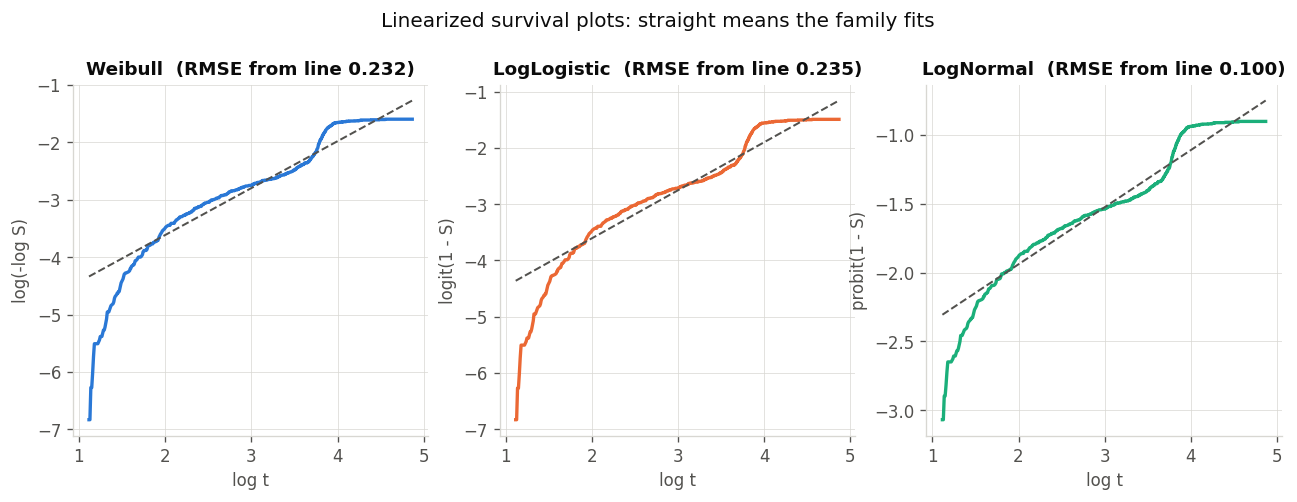

In [14]:
km_frame = kmf.survival_function_.reset_index()
km_frame.columns = ["t", "S"]
km_frame = km_frame[(km_frame["t"] > 0) & (km_frame["S"] > 0.001) & (km_frame["S"] < 0.999)]
log_t = np.log(km_frame["t"])

transforms = [
    ("Weibull", np.log(-np.log(km_frame["S"])), "log(-log S)"),
    ("LogLogistic", np.log((1 - km_frame["S"]) / km_frame["S"]), "logit(1 - S)"),
    ("LogNormal", norm.ppf(1 - km_frame["S"]), "probit(1 - S)"),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, (name, y, ylabel), colour in zip(axes, transforms, PALETTE):
    ax.plot(log_t, y, color=colour, linewidth=2)
    coeffs = np.polyfit(log_t, y, 1)
    ax.plot(log_t, np.polyval(coeffs, log_t), color=MUTED, linestyle="--", linewidth=1.2)
    residual = np.sqrt(np.mean((y - np.polyval(coeffs, log_t)) ** 2))
    ax.set_title(f"{name}  (RMSE from line {residual:.3f})")
    ax.set_xlabel("log t")
    ax.set_ylabel(ylabel)
fig.suptitle("Linearized survival plots: straight means the family fits", y=1.04)
save(fig, "07_linearized_goodness_of_fit.png")
plt.show()

All three are visibly bent rather than straight, and they bend in the same
place — the shoulder at roughly 40-50 months where four-year contracts come up
for renewal. This is the graphical form of what the AIC table already implies:
no two-parameter family reproduces the shape of this hazard, which is why the
flexible three-parameter generalized gamma wins.

### What the selected model implies, and where it still falls short

P(observable successor within 12 months | none by this age)


,Kaplan-Meier,Exponential,Weibull,LogLogistic,LogNormal,GeneralizedGamma
contract age,,,,,,
0,0.046,0.028,0.039,0.039,0.038,0.043
12,0.022,0.028,0.030,0.031,0.034,0.042
24,0.021,0.028,0.027,0.028,0.030,0.030
36,0.075,0.028,0.026,0.026,0.027,0.024
48,0.024,0.028,0.024,0.025,0.024,0.019


saved data/processed/boamp_v2/figures/survival_analysis/08_parametric_vs_empirical.png


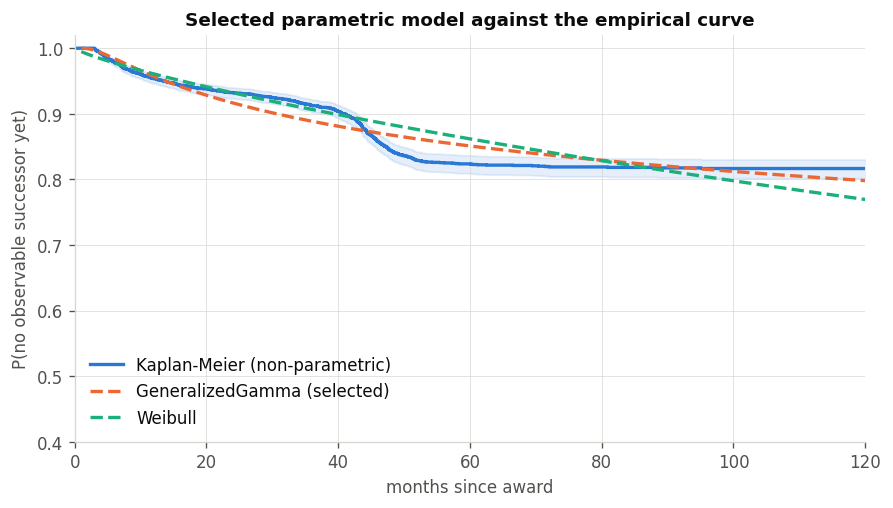

In [15]:
comparison = pd.DataFrame([
    {"contract age": age,
     "Kaplan-Meier": round(conditional_probability(kmf, age, 12), 3),
     **{name: round(conditional_probability(fitter, age, 12), 3)
        for name, fitter in families.items()}}
    for age in (0, 12, 24, 36, 48)
]).set_index("contract age")
print("P(observable successor within 12 months | none by this age)")
display(comparison)

fig, ax = plt.subplots(figsize=(8.5, 4.4))
timeline = np.linspace(1, 120, 240)
kmf.plot_survival_function(ax=ax, color=PALETTE[0], linewidth=2, ci_alpha=0.12,
                           label="Kaplan-Meier (non-parametric)")
for i, name in enumerate([best_name, "Weibull"]):
    values = np.asarray(families[name].survival_function_at_times(timeline)).ravel()
    ax.plot(timeline, values, linewidth=2, linestyle="--", color=PALETTE[i + 1],
            label=f"{name}{' (selected)' if name == best_name else ''}")
ax.set_xlabel("months since award")
ax.set_ylabel("P(no observable successor yet)")
ax.set_xlim(0, 120)
ax.set_ylim(0.4, 1.02)
ax.set_title("Selected parametric model against the empirical curve")
ax.legend(loc="lower left")
save(fig, "08_parametric_vs_empirical.png")
plt.show()

The selected model tracks the overall level well, and if this study needed to
extrapolate past 2025 the generalized gamma is what it would use.

For the operational question it is still the wrong instrument, and the age-36
row of the table shows why. A contract three years old sits just before the
renewal shoulder; Kaplan-Meier puts its 12-month probability near 0.075, while
every parametric family — the selected one included — reports roughly 0.02-0.03.
The families disagree with each other by very little and with the data by a
factor of three, at precisely the moment a central purchasing body would want
the warning.

That is not an argument against parametric modelling in general. It is the
specific consequence of a smooth family being asked to represent a procurement
cycle with a shoulder in it. Since every horizon this study reports falls
*inside* the observed window, the extrapolation that would justify accepting
that smoothing is not needed here.

**Decision.** The generalized gamma is reported as the selected parametric
model, chosen on AIC and BIC and checked graphically. The operational
probabilities in section 6 come from Kaplan-Meier, which imposes no shape.

## 9. Evidence / Decision

**What was tested.** How long a digital Grand Ouest public contract runs before
an observable successor procurement appears, whether that differs by segment,
and what 12- and 24-month probabilities follow.

**What data were used.** 3,800 contracts awarded 2015-2025, of which 547 have
an accepted observable successor and 3,253 are right-censored at 2025-12-31,
under the frozen `M_B_text_ranking @ 70` linkage policy.

**Main quantitative results.** Reported in the tables above: the overall
Kaplan-Meier curve with 12- and 24-month survival, per-segment curves with a
log-rank comparison, a five-covariate Cox model with hazard ratios and
concordance, and conditional 12/24-month probabilities by contract age and
segment.

**What the diagnostics show.** All structural checks pass. Every segment clears
the 30-event minimum. The proportional-hazards test is reported explicitly, and
any violating covariate is described as a time-averaged effect. The sensitivity
analysis shows how far the estimates move across a fourfold range in event
count.

**What problems remain.** Four limitations bound every number here.
*Linkage incompleteness*: only about 14% of contracts receive an accepted link,
so these are lower bounds on real re-procurement, not renewal rates.
*Recent-year short gaps*: contracts awarded in 2024-2025 contribute only
short-gap events (every 2025 event is under twelve months, median 6.6). Some of
this is structural, since a recent award cannot yet have a long gap and
censoring accounts for the unequal follow-up, but the residue may be follow-on
procurement rather than renewal and would inflate the 12-month figure
specifically.
*Benchmark limitations*: measured linkage recall is optimistic and no clean
holdout exists, so the event set's quality is known less precisely than the
figures suggest.
*Censoring is not absence*: a censored contract may well have been renewed
outside BOAMP, through a central purchasing body such as Gigalis itself, or
below publication thresholds.

**Decision.** The survival layer is complete and reproducible. The 12/24-month
conditional probabilities are the deliverable, to be read as **the probability
that a new purchasing need becomes visible in BOAMP**, stratified by segment
and contract age, with the sensitivity table attached whenever they are quoted.

Two things should be quoted together with them. Absolute probabilities move by
roughly a factor of six across the sensitivity arms, so they are lower bounds
whose level depends on linkage strictness. What is stable is the *relative*
picture: the segment ordering is unchanged across three of the four arms, and
the log-rank test separates the segments at p < 0.001. The defensible claim is
therefore comparative — which segments re-procure sooner — rather than a
calibrated absolute rate.

**Can the next stage proceed?** Yes. The remaining work is written synthesis,
not further modelling. Descriptive technology trends remain optional and were
not required for this conclusion.